<a href="https://colab.research.google.com/github/adelinda02/Tugas-5-Analisis-Visualisasi-Data/blob/main/tgs_5_analisis_dan_visualisasi_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama: Ade Linda Febriana Nim: 41823020001 Tugas 5 latihan clustering**

2. a. Buatlah EDA untuk membantu menyelesaikan permasalahan tersebut

import library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

load dataset

In [4]:
df = pd.read_csv('train.csv')

menampilkan data awal

In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


melihat informasi dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

memeriksa jumlah baris & kolom

In [7]:
df.shape

(1460, 81)

Memeriksa missing value

In [ ]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


cek nama kolom

In [66]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

memeriksa duplikasi data

In [ ]:
df.duplicated().sum()

np.int64(0)

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

statistik deskriptif

In [ ]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Distribusi Harga Rumah (SalePrice)

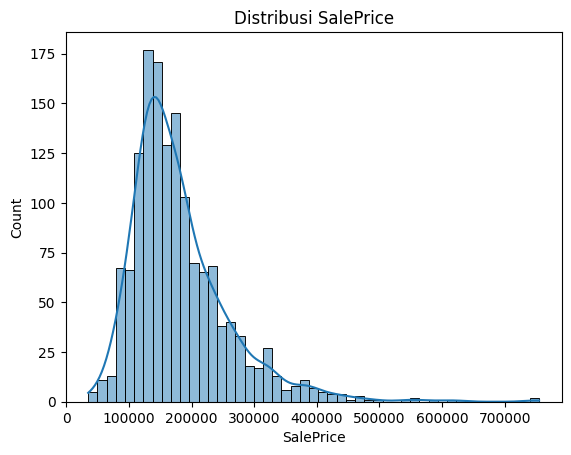

In [ ]:
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribusi SalePrice")
plt.show()

Top 10 Fitur yang Paling Berpengaruh Terhadap SalePrice

In [11]:
corr = df.corr(numeric_only=True)

top_corr = corr['SalePrice'].sort_values(
    ascending=False
)

print(top_corr.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


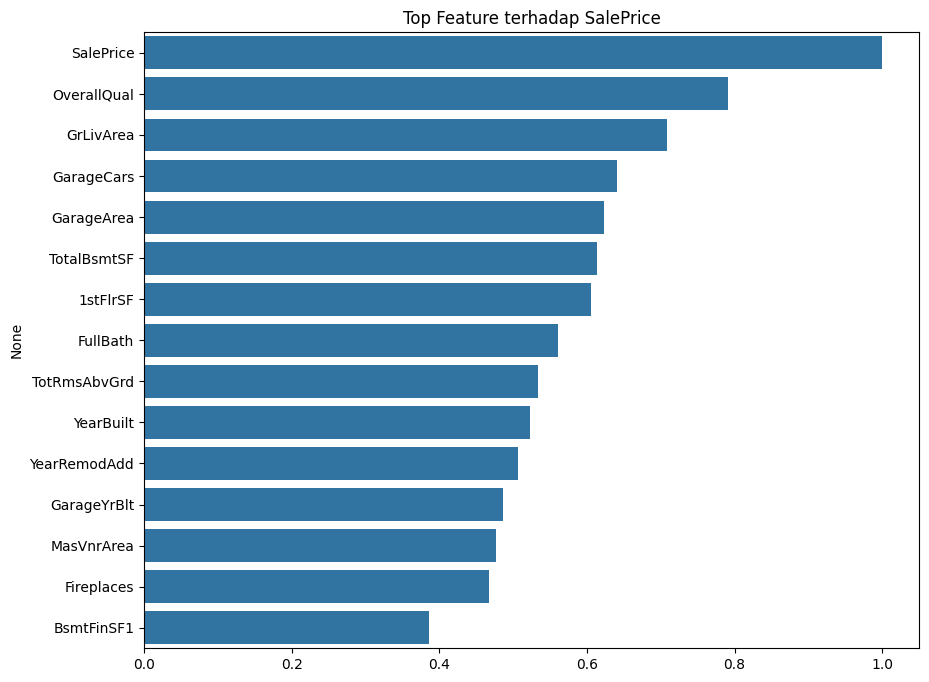

In [10]:
plt.figure(figsize=(10,8))

top_features = top_corr.head(15)

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top Feature terhadap SalePrice")
plt.show()

Korelasi Antar Variabel Numerik

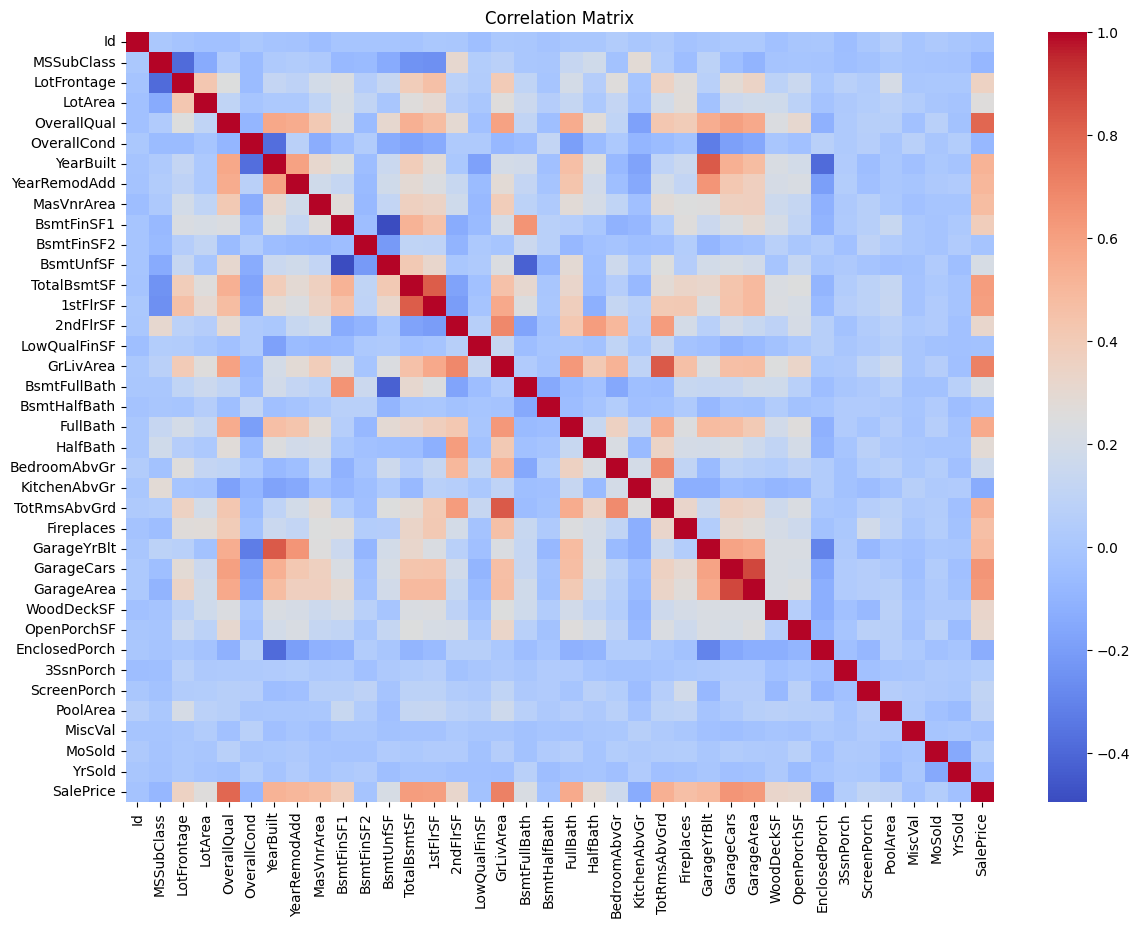

In [9]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

Hubungan Top Fitur(OverallQual) dengan SalePrice

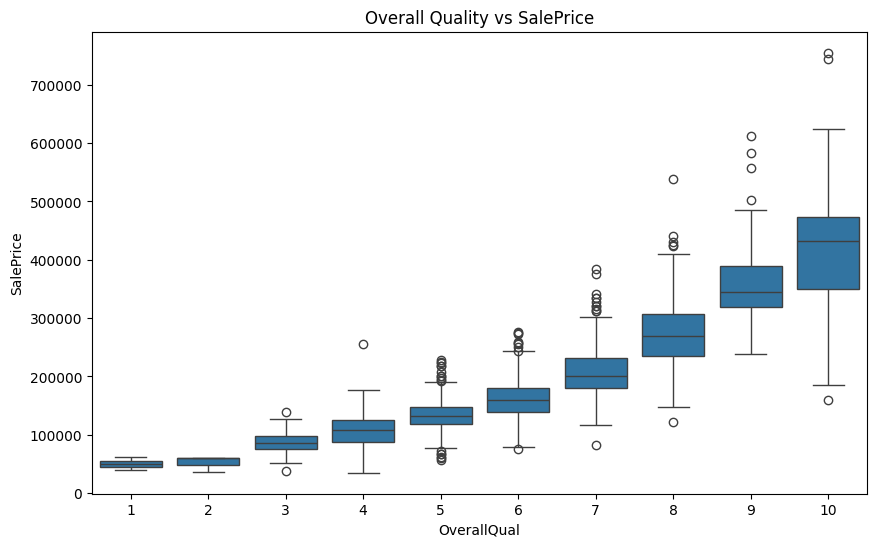

In [40]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='OverallQual',
    y='SalePrice',
    data=df
)

plt.title('Overall Quality vs SalePrice')
plt.show()

Semakin tinggi kualitas bangunan, semakin tinggi harga rumah.

Hubungan GrLivArea dengan SalePrice

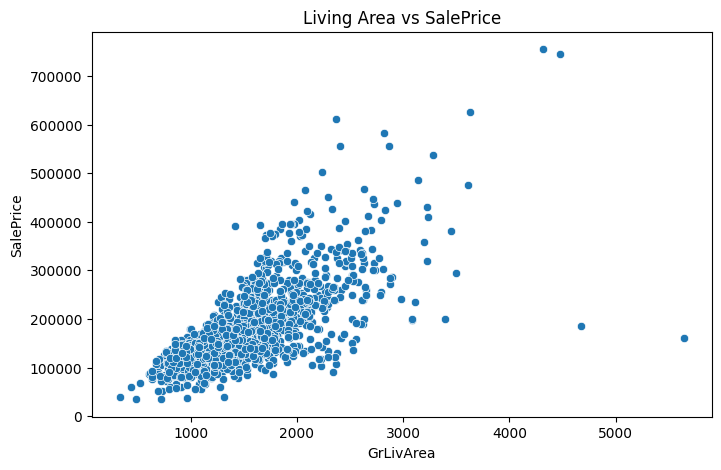

In [41]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='GrLivArea',
    y='SalePrice',
    data=df
)

plt.title('Living Area vs SalePrice')
plt.show()

Semakin luas area hunian, semakin mahal harga rumah

SalePrice Berdasarkan Neighborhood

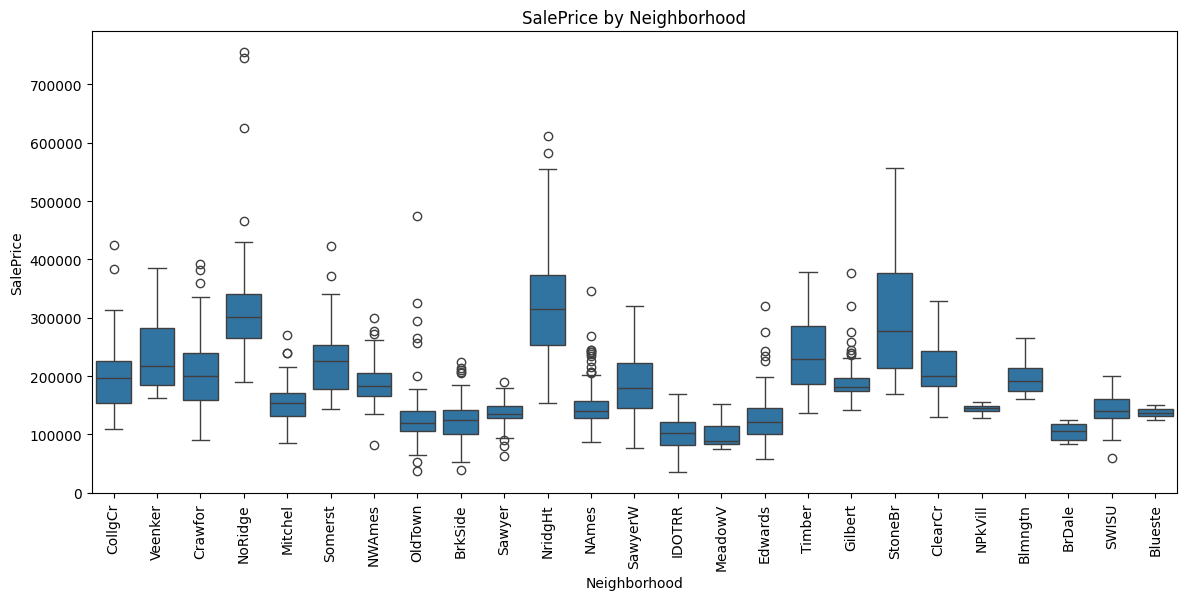

In [42]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x='Neighborhood',
    y='SalePrice',
    data=df
)

plt.xticks(rotation=90)

plt.title('SalePrice by Neighborhood')
plt.show()

Distribusi Tahun Pembangunan

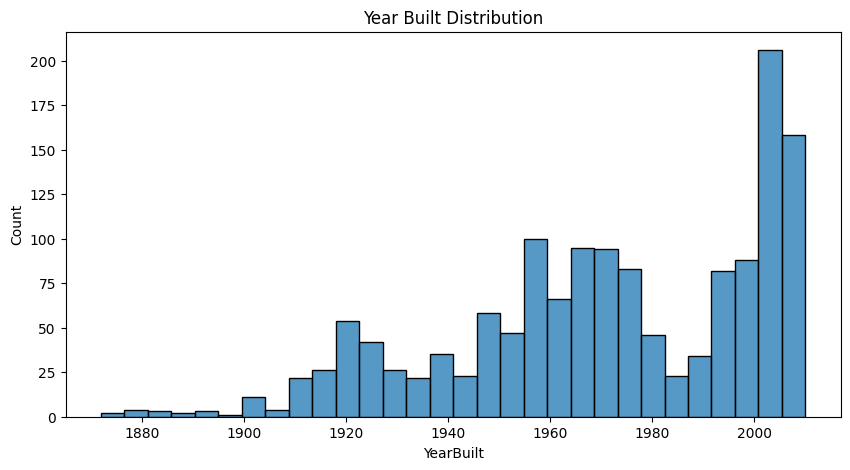

In [43]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['YearBuilt'],
    bins=30
)

plt.title('Year Built Distribution')
plt.show()

b. Lakukanlah feature engineering

memisahkan Target dan Fitur

In [12]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

memisahkan Kolom Numerik dan Kategorikal

In [13]:
num_cols = X.select_dtypes(
    include=['int64','float64']
).columns

cat_cols = X.select_dtypes(
    include=['object']
).columns

One Hot Encoding

In [16]:
X = pd.get_dummies(X)

X = X.fillna(X.median())

In [68]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageYrBlt,81
GarageFinish,81


2.B.1. Jika dirasa data memiliki data terlalu besar lakukanlah Dimension reduction

Standardisasi

In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

PCA

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X_scaled)

print("Dimensi awal :", X.shape[1])
print("Dimensi setelah PCA :", X_pca.shape[1])

Dimensi awal : 288
Dimensi setelah PCA : 183


Pada tahap feature engineering dilakukan penanganan missing value menggunakan median untuk atribut numerik dan modus untuk atribut kategorikal. Selanjutnya atribut kategorikal diubah menjadi numerik menggunakan One-Hot Encoding. Karena jumlah fitur cukup besar setelah proses encoding, dilakukan dimension reduction menggunakan Principal Component Analysis (PCA) dengan mempertahankan 95% informasi data.

2. B. 2 Buatlah model clustering untuk dapat memahami segmentasi dari pelanggan

Menentukan Nilai K (Elbow Method)

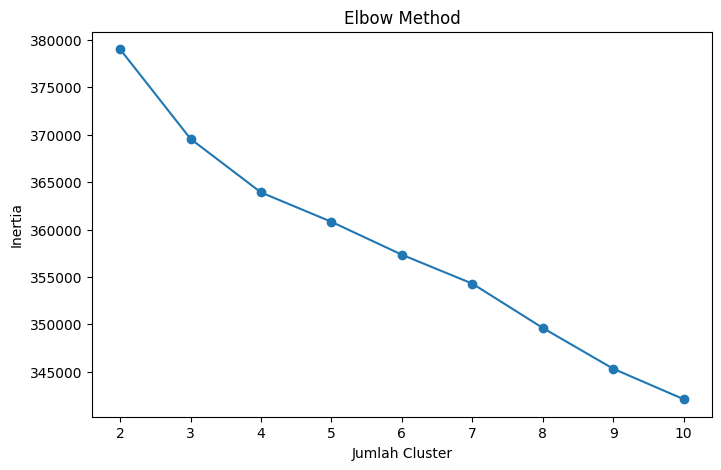

In [21]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_pca)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker='o')

plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [49]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster = kmeans.fit_predict(X_pca)

df['Cluster'] = cluster

Metode K-Means digunakan untuk mengelompokkan data rumah ke dalam beberapa cluster. Penentuan jumlah cluster dilakukan menggunakan Elbow Method sehingga diperoleh nilai K yang optimal. Hasil clustering menunjukkan bahwa rumah dapat dikelompokkan berdasarkan karakteristik harga, kualitas bangunan, dan luas area hunian.

Evaluasi Clustering

In [70]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_pca
    )

    score = silhouette_score(
        X_pca,
        labels
    )

    print(
        f'K={k} -> Silhouette Score={score:.4f}'
    )

K=2 -> Silhouette Score=0.0514
K=3 -> Silhouette Score=0.0400
K=4 -> Silhouette Score=0.0146
K=5 -> Silhouette Score=0.0154
K=6 -> Silhouette Score=-0.0257
K=7 -> Silhouette Score=0.0122
K=8 -> Silhouette Score=-0.0213
K=9 -> Silhouette Score=-0.0086
K=10 -> Silhouette Score=0.0129


In [24]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_pca,
    cluster
)

print("Silhouette Score =", score)

Silhouette Score = 0.042114113244060565


In [67]:
from sklearn.metrics import davies_bouldin_score

dbi = davies_bouldin_score(X_pca, cluster)
print(dbi)

4.357246865237248


Evaluasi dilakukan menggunakan Silhouette Score. Nilai Silhouette Score yang diperoleh menunjukkan bahwa objek dalam cluster memiliki tingkat kemiripan yang baik dengan anggota cluster yang sama dan cukup berbeda dengan cluster lainnya. Dengan demikian model clustering mampu membentuk segmentasi yang cukup representatif.

Visualisasi Cluster

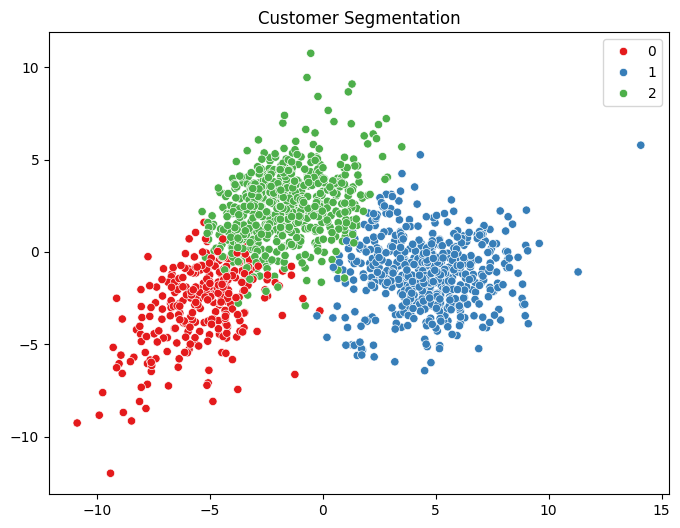

In [25]:
pca2 = PCA(n_components=2)

X_vis = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_vis[:,0],
    y=X_vis[:,1],
    hue=cluster,
    palette='Set1'
)

plt.title('Customer Segmentation')
plt.show()

Analisis Segmentasi

In [26]:
segmentasi = df.groupby(
    'Cluster'
)['SalePrice'].agg([
    'count',
    'mean',
    'min',
    'max'
])

print(segmentasi)

         count           mean     min     max
Cluster                                      
0          287  121944.372822   34900  475000
1          563  241681.852575  130000  755000
2          610  152590.209836   60000  381000


In [51]:
segmentasi = df.groupby('Cluster')[[
    'SalePrice',
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'TotalBsmtSF',
    'YearBuilt'
]].mean().round(2)

print(segmentasi)

         SalePrice  OverallQual  GrLivArea  GarageCars  TotalBsmtSF  YearBuilt
Cluster                                                                       
0        242478.95         7.31    1766.69        2.30      1268.77    2001.23
1        153974.96         5.48    1359.25        1.57      1004.79    1965.66
2        121172.53         5.11    1370.17        1.18       767.32    1926.18


Berdasarkan hasil clustering diperoleh tiga segmen utama:

Cluster 0

Rumah dengan harga rendah, kualitas bangunan standar, dan luas bangunan relatif kecil.

Cluster 1

Rumah dengan harga menengah dan karakteristik bangunan yang cukup baik.

Cluster 2

Rumah premium dengan harga tinggi, kualitas bangunan sangat baik, dan luas area yang lebih besar dibanding cluster lainnya.

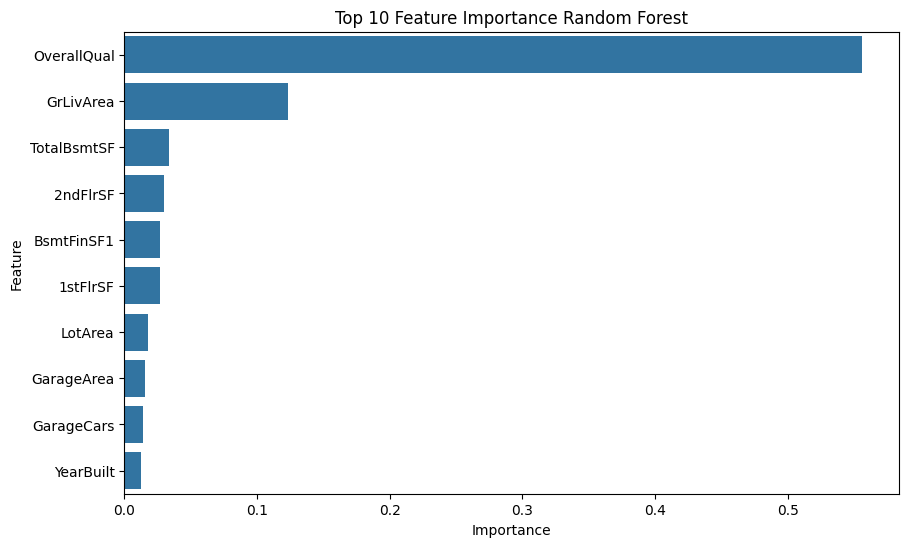

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importance Random Forest')
plt.show()

c. Buatlah Model klasifikasinya dengan menggunakan model Random Forest maupun
XGBoost

SPLIT DATA RANDOM FOREST

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Training Random Forest

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Evaluasi Random Forest

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(
    y_test,
    rf_pred
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

r2_rf = r2_score(
    y_test,
    rf_pred
)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R2 :", r2_rf)

Random Forest
MAE : 17680.29315068493
RMSE : 29553.66622042083
R2 : 0.8861301118784692


Feature Importance

In [60]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

        Feature  Importance
4   OverallQual    0.556261
16    GrLivArea    0.122977
12  TotalBsmtSF    0.033355
14     2ndFlrSF    0.029898
9    BsmtFinSF1    0.027150
13     1stFlrSF    0.026827
3       LotArea    0.017568
27   GarageArea    0.015165
26   GarageCars    0.014143
6     YearBuilt    0.012767


Random Forest digunakan untuk memprediksi harga rumah berdasarkan fitur yang tersedia. Model dilatih menggunakan data training dan dievaluasi menggunakan MAE, RMSE, dan R² Score. Selain itu dilakukan analisis feature importance untuk mengetahui fitur yang paling berpengaruh terhadap harga rumah.

XGBoost
Training

In [34]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

Evaluasi XGBoost

In [35]:
mae_xgb = mean_absolute_error(
    y_test,
    xgb_pred
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

r2_xgb = r2_score(
    y_test,
    xgb_pred
)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE :", rmse_xgb)
print("R2 :", r2_xgb)

XGBoost
MAE : 15501.232421875
RMSE : 25127.926138064002
R2 : 0.917681097984314


XGBoost digunakan sebagai model pembanding karena memiliki kemampuan menangani hubungan non-linear yang kompleks. Evaluasi dilakukan menggunakan metrik yang sama dengan Random Forest sehingga performa kedua model dapat dibandingkan secara objektif.

Perbandingan Model

In [36]:
hasil = pd.DataFrame({
    'Model':['Random Forest','XGBoost'],
    'MAE':[mae_rf, mae_xgb],
    'RMSE':[rmse_rf, rmse_xgb],
    'R2':[r2_rf, r2_xgb]
})

print(hasil)

           Model           MAE          RMSE        R2
0  Random Forest  17680.293151  29553.666220  0.886130
1        XGBoost  15501.232422  25127.926138  0.917681


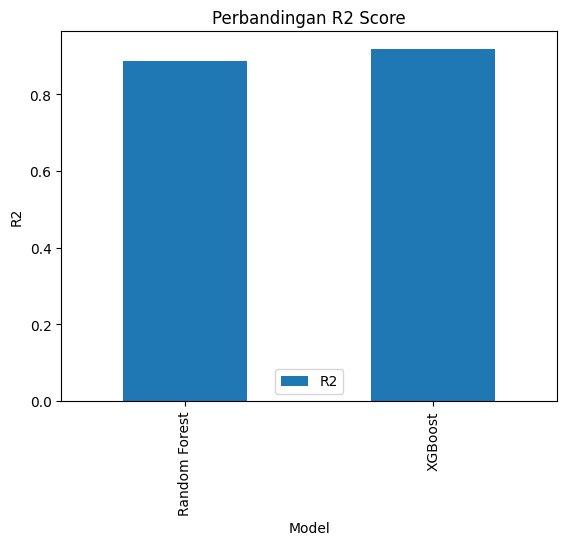

In [53]:
import matplotlib.pyplot as plt

hasil.set_index('Model')[['R2']].plot(
    kind='bar'
)

plt.title('Perbandingan R2 Score')
plt.ylabel('R2')
plt.show()

In [64]:
best_model = hasil.loc[
    hasil['R2'].idxmax(),
    'Model'
]

print("Model terbaik:", best_model)

Model terbaik: XGBoost
